# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to determine how sole material, insole thickness, and fabric breathability affect the comfort of the new running shoe model, and to identify which combination of these factors appears to give the highest comfort ratings.

2.  Specify the outcome variable and how it is measured.

The outcome variable is a **quantitative, approximately continuous variable** representing the comfort rating of the shoe after a 30-minute treadmill run. It is measured on a scale from 1 to 10, where higher values indicate greater comfort.

3.  Specify the independent variables. What lurking variables may be present?

The independent variables are:

- **Sole Material (A)**: Standard EVA foam vs Advanced gel-infused foam  
- **Insole Thickness (B)**: 3mm vs 6mm  
- **Fabric Breathability (C)**: Standard woven fabric vs High-performance mesh fabric  

Some possible lurking variables include:

- athlete foot shape or arch type  
- running style or stride pattern  
- prior preference for certain shoe materials  
- treadmill pace or running intensity  
- fatigue level before testing  
- sock type or shoe fit  
- minor manufacturing differences other than the three factors being studied

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

A **full factorial design** studies all possible treatment combinations of the factors and levels included in the experiment. In general, a full factorial design may involve factors with different numbers of levels.

A **\(2^k\) factorial design** is a specific type of full factorial design in which there are **k factors**, and each factor has exactly **2 levels**. In this experiment, there are 3 factors and 2 levels for each factor, so the design is a **\(2^3\) factorial design**, which gives **8 total treatment combinations**.

A \(2^k\) design may be preferred here because all three factors naturally have two levels, and the design allows the company to study not only the main effects of each factor, but also their interaction effects, while still keeping the number of treatment combinations manageable.

5.  State the sets of null and alternative hypotheses for this experiment.

Let

- $\mu_{A-}$, $\mu_{A+}$ = mean comfort ratings for sole material (EVA, Gel)  
- $\mu_{B-}$, $\mu_{B+}$ = mean comfort ratings for insole thickness (3mm, 6mm)  
- $\mu_{C-}$, $\mu_{C+}$ = mean comfort ratings for fabric breathability (Woven, Mesh)  

We test for main effects and interaction effects in the $2^3$ factorial design.

**Main effect of A (sole material)**  
$$
H_0: \mu_{A-} = \mu_{A+}
$$
$$
H_A: \mu_{A-} \ne \mu_{A+}
$$

**Main effect of B (insole thickness)**  
$$
H_0: \mu_{B-} = \mu_{B+}
$$
$$
H_A: \mu_{B-} \ne \mu_{B+}
$$

**Main effect of C (fabric breathability)**  
$$
H_0: \mu_{C-} = \mu_{C+}
$$
$$
H_A: \mu_{C-} \ne \mu_{C+}
$$

**Two-way interaction effects**  
$$
H_0: AB = AC = BC = 0
$$
$$
H_A: \text{At least one of } AB, AC, BC \ne 0
$$

**Three-way interaction effect**  
$$
H_0: ABC = 0
$$
$$
H_A: ABC \ne 0
$$
6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [1]:
## Question 6 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_excel("Shoe Comfort Experiment.xlsx")

data.head()

,sole_material,insole_thickness,breathability,comfort
0,EVA,3mm,Woven,6.373546
1,EVA,3mm,Woven,7.183643
2,EVA,3mm,Woven,6.164371
3,EVA,3mm,Mesh,7.595281
4,EVA,3mm,Mesh,6.329508


In [2]:
# Overall summary
data["comfort"].describe()

,comfort
count,24.000000
mean,8.068617
std,1.639462
min,5.179532
25%,6.841637
50%,7.997795
75%,8.816883
max,11.168977


In [3]:
# By each factor
data.groupby("sole_material")["comfort"].describe()

,count,mean,std,min,25%,50%,75%,max
sole_material,,,,,,,,
EVA,12.0,7.093638,1.076122,5.179532,6.295784,7.036743,8.080693,8.538325
Gel,12.0,9.043596,1.545309,6.710648,7.976624,8.859201,10.379674,11.168977


In [4]:
data.groupby("insole_thickness")["comfort"].describe()

,count,mean,std,min,25%,50%,75%,max
insole_thickness,,,,,,,,
3mm,12.0,7.441465,1.387030,5.179532,6.362537,7.389462,8.107547,10.224931
6mm,12.0,8.695768,1.684642,6.194612,7.731297,8.457053,9.822578,11.168977


In [5]:
data.groupby("breathability")["comfort"].describe()

,count,mean,std,min,25%,50%,75%,max
breathability,,,,,,,,
Mesh,12.0,7.504218,1.272221,5.179532,6.615363,7.775174,8.202477,9.482136
Woven,12.0,8.633016,1.818369,6.164371,7.109058,8.427270,10.379674,11.168977


In [6]:
# By all combinations
data.groupby(["sole_material", "insole_thickness", "breathability"])["comfort"].mean()

sole_material  insole_thickness  breathability
EVA            3mm               Mesh              6.368107
                                 Woven             6.573854
               6mm               Mesh              7.032079
                                 Woven             8.400512
Gel            3mm               Mesh              8.294237
                                 Woven             8.529663
               6mm               Mesh              8.322450
                                 Woven            11.028033
Name: comfort, dtype: float64

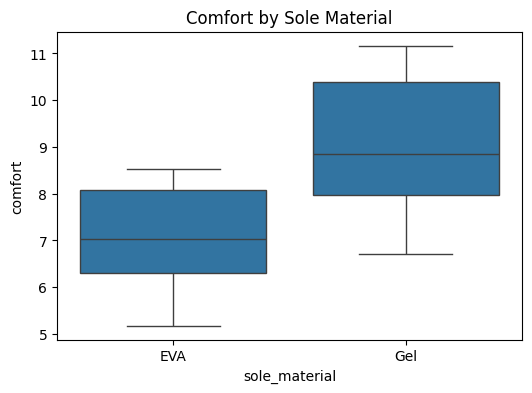

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sole_material", y="comfort", data=data)
plt.title("Comfort by Sole Material")
plt.show()

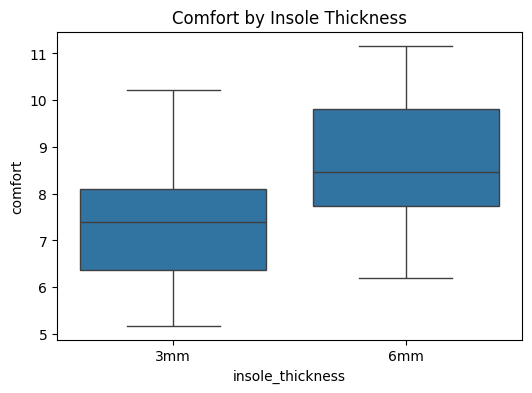

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x="insole_thickness", y="comfort", data=data)
plt.title("Comfort by Insole Thickness")
plt.show()

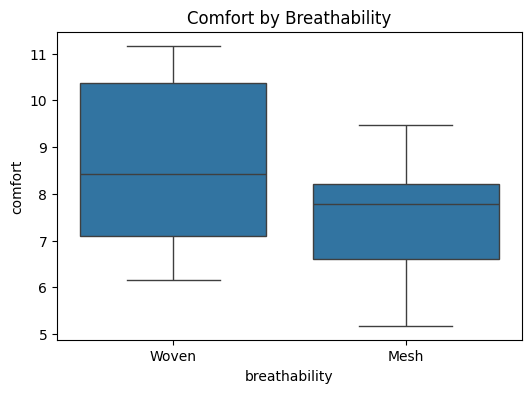

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="breathability", y="comfort", data=data)
plt.title("Comfort by Breathability")
plt.show()

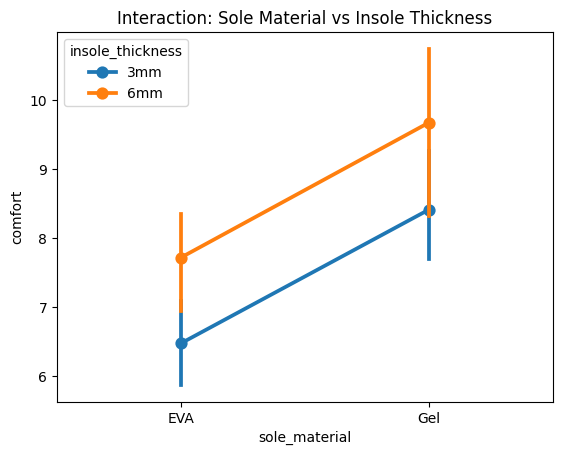

In [10]:
sns.pointplot(x="sole_material", y="comfort", hue="insole_thickness", data=data)
plt.title("Interaction: Sole Material vs Insole Thickness")
plt.show()

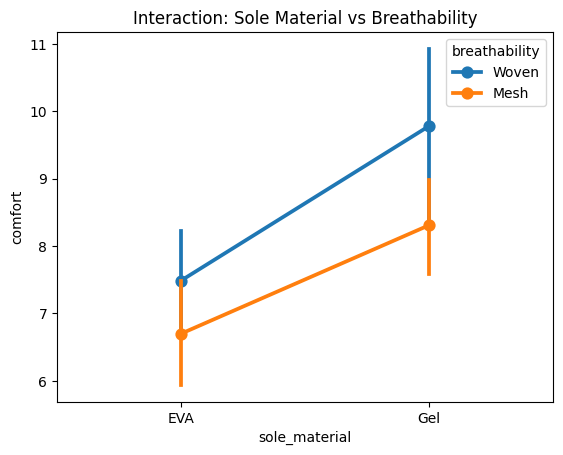

In [11]:
sns.pointplot(x="sole_material", y="comfort", hue="breathability", data=data)
plt.title("Interaction: Sole Material vs Breathability")
plt.show()

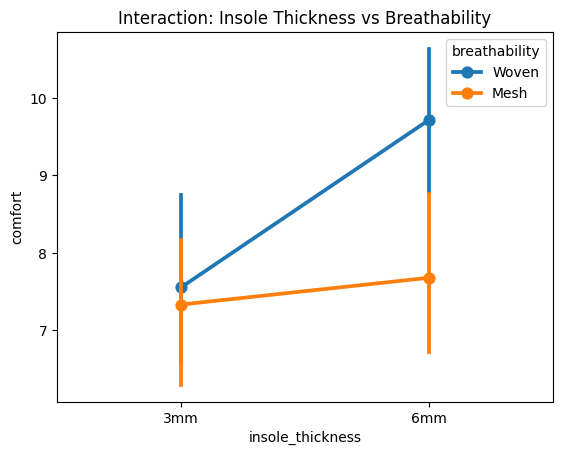

In [12]:
sns.pointplot(x="insole_thickness", y="comfort", hue="breathability", data=data)
plt.title("Interaction: Insole Thickness vs Breathability")
plt.show()

Exploratory analysis was performed using summary statistics, boxplots, and interaction plots to examine how comfort ratings vary across the three factors.

The summary statistics and boxplots show noticeable differences across all three main factors. Shoes with **Gel** soles have higher comfort ratings overall than shoes with **EVA** soles. Shoes with **6mm** insoles also tend to have higher comfort ratings than shoes with **3mm** insoles. For breathability, the **Woven** condition appears higher overall than the **Mesh** condition, although the difference is less visually distinct and the Woven group shows more variability.

The treatment-combination means also show clear differences. The highest average comfort rating is observed for **Gel + 6mm + Woven** (11.028), while the lowest average is observed for **EVA + 3mm + Mesh** (6.368). This suggests that the factor levels do not all produce the same comfort ratings.

The interaction plots provide additional insight. The plot for **sole material and insole thickness** shows nearly parallel lines, indicating little to no interaction between these two factors. The plot for **sole material and breathability** shows some difference in slopes, suggesting a possible interaction. The strongest visual evidence of interaction appears in the plot for **insole thickness and breathability**, where increasing thickness leads to a much larger increase in comfort under the Woven condition than under the Mesh condition.

Overall, the exploratory analysis suggests that the main effects are not equal and that at least some interaction effects may also be present. Therefore, these results support the **alternative hypotheses** more strongly than the null hypotheses.

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


In [13]:
## Question 7 Code ##
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Fit full factorial model (includes all interactions)
model = smf.ols("comfort ~ sole_material * insole_thickness * breathability", data=data).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
sole_material,22.814025,1.0,23.353723,0.000184
insole_thickness,9.439657,1.0,9.662965,0.006758
breathability,7.645101,1.0,7.825956,0.012908
sole_material:insole_thickness,0.000485,1.0,0.000496,0.982504
sole_material:breathability,0.700584,1.0,0.717157,0.409567
insole_thickness:breathability,4.949082,1.0,5.066160,0.038812
sole_material:insole_thickness:breathability,0.641055,1.0,0.656220,0.429782
Residual,15.630245,16.0,NaN,NaN


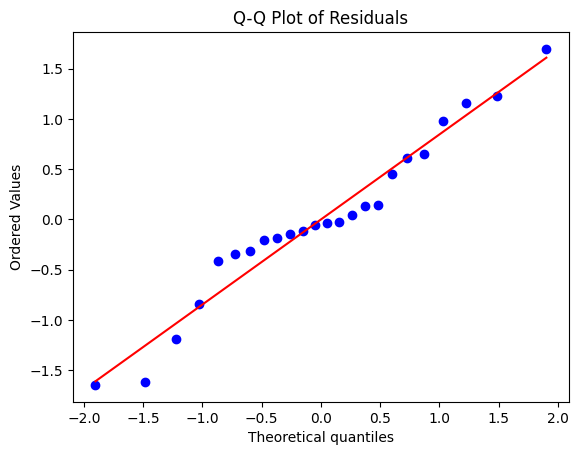

In [14]:
import scipy.stats as stats
import matplotlib.pyplot as plt

residuals = model.resid

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [15]:
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk Test Statistic: 0.959532741725587
p-value: 0.42910705030991836


A full factorial ANOVA model was fit to the data, including all main effects and interaction terms for sole material, insole thickness, and breathability.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro-Wilk test.

From the Q-Q plot, the residuals lie reasonably close to the reference line overall. There are some mild deviations, particularly in the lower tail and slightly around the center, but these deviations are not large and there is no clear systematic pattern such as strong curvature. This suggests that the residuals are approximately normally distributed.

The Shapiro-Wilk test provides a formal assessment of normality. The p-value is 0.429, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality, indicating that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

Overall, although there are minor deviations visible in the Q-Q plot, both the visual and formal methods suggest that the normality assumption is reasonably satisfied for this model.


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


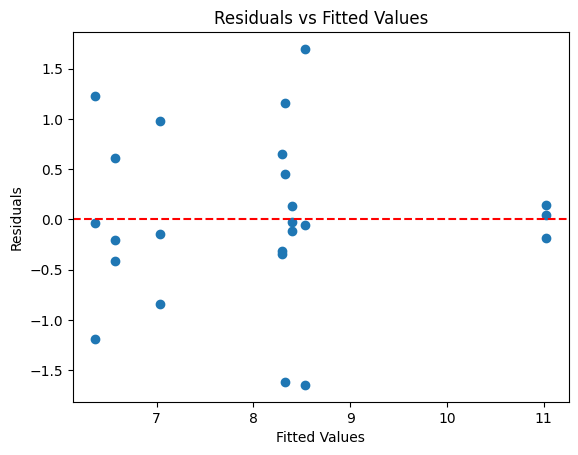

In [16]:
## Question 8 Code ##
import matplotlib.pyplot as plt

fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model.model.exog)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("Breusch-Pagan Test Statistic:", bp_stat)
print("p-value:", bp_pvalue)

Breusch-Pagan Test Statistic: 11.936143071891754
p-value: 0.1026784910142485


The constant variance assumption was assessed using both a residuals versus fitted values plot and the Breusch-Pagan test.

From the residuals versus fitted values plot, the residuals appear to be randomly scattered around zero with no clear pattern or systematic structure. There is no evident funnel shape. While there are small differences in the spread of residuals at different fitted values, these differences are not consistent or systematic.

The Breusch-Pagan test provides a formal assessment of constant variance. The p-value is 0.103, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant variance, indicating that there is no strong statistical evidence of heteroscedasticity.

Overall, both the visual and formal methods suggest that the constant variance assumption is reasonably satisfied for this model.


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


The factorial ANOVA model produced the following results:

- **Sole Material:** \(F = 23.354\; p = 0.000184\)
- **Insole Thickness:** \(F = 9.663\; p = 0.006758\)
- **Breathability:** \(F = 7.826\; p = 0.012908\)
- **Sole Material × Insole Thickness:** \(F = 0.000496\; p = 0.982504\)
- **Sole Material × Breathability:** \(F = 0.717\; p = 0.409567\)
- **Insole Thickness × Breathability:** \(F = 5.066,\; p = 0.038812\)
- **Sole Material × Insole Thickness × Breathability:** \(F = 0.656\; p = 0.429782\)

Based on these results, all three **main effects** are statistically significant at the 0.05 level. This suggests that sole material, insole thickness, and breathability each have an effect on mean comfort ratings.

For the **two-way interactions**, the interaction between **sole material and insole thickness** is not statistically significant, and the interaction between **sole material and breathability** is also not statistically significant. However, the interaction between **insole thickness and breathability** is statistically significant, which suggests that the effect of insole thickness on comfort depends on the level of breathability.

For the **three-way interaction**, the interaction among sole material, insole thickness, and breathability is not statistically significant. This suggests that there is no evidence that the combined interaction of all three factors has an effect on comfort beyond the lower-order effects.


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [18]:
## Question 10 Code ##
# Partial eta-squared for each effect
ss_error = anova_table.loc["Residual", "sum_sq"]

partial_eta_sq = {}
for effect in anova_table.index[:-1]:   # exclude Residual
    ss_effect = anova_table.loc[effect, "sum_sq"]
    partial_eta_sq[effect] = ss_effect / (ss_effect + ss_error)

partial_eta_sq

{'sole_material': np.float64(0.5934310972284753),
 'insole_thickness': np.float64(0.3765334696156392),
 'breathability': np.float64(0.32846347365240514),
 'sole_material:insole_thickness': np.float64(3.10101153619039e-05),
 'sole_material:breathability': np.float64(0.042899454464646165),
 'insole_thickness:breathability': np.float64(0.24048804576145394),
 'sole_material:insole_thickness:breathability': np.float64(0.039397922869394114)}

The partial \(\eta^2\) values were calculated using

$$
\eta_p^2=\frac{SS_{\text{effect}}}{SS_{\text{effect}}+SS_{\text{error}}}
$$

The resulting values are:

- **Sole Material:** \(\eta_p^2 = 0.593\)
- **Insole Thickness:** \(\eta_p^2 = 0.377\)
- **Breathability:** \(\eta_p^2 = 0.328\)
- **Sole Material × Insole Thickness:** \(\eta_p^2 \approx 0.000\)
- **Sole Material × Breathability:** \(\eta_p^2 = 0.043\)
- **Insole Thickness × Breathability:** \(\eta_p^2 = 0.240\)
- **Sole Material × Insole Thickness × Breathability:** \(\eta_p^2 = 0.039\)

These results indicate that the most important factor is **sole material**, as it has the largest partial \(\eta^2\) value and explains the greatest proportion of variability in comfort ratings after accounting for the other effects in the model.

Among the remaining main effects, **insole thickness** and **breathability** also show moderate effect sizes, suggesting that they contribute meaningfully to explaining variation in comfort.

For the interaction effects, the most important is **insole thickness × breathability**, with a partial \(\eta^2\) of 0.240. This indicates that the effect of insole thickness on comfort depends on the level of breathability, which is consistent with the ANOVA results where this interaction was statistically significant.

The other interaction effects, including **sole material × insole thickness**, **sole material × breathability**, and the **three-way interaction**, have relatively small partial \(\eta^2\) values. This suggests that they contribute little to explaining variability in comfort ratings compared to the main effects and the insole thickness × breathability interaction.

11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

Based on the results of the factorial ANOVA and exploratory analysis, all three main factors — sole material, insole thickness, and breathability — have a statistically significant effect on comfort ratings. Among these, **sole material** has the largest effect, followed by **insole thickness** and **breathability**, as indicated by both the ANOVA results and the partial \(\eta^2\) values.

In addition, there is a statistically significant interaction between **insole thickness and breathability**, indicating that the effect of insole thickness on comfort depends on the type of fabric used. This was also supported by the interaction plots, where increasing thickness from 3mm to 6mm resulted in a much larger increase in comfort under the **Woven** condition than under the **Mesh** condition.

The treatment-combination means further support these findings. The highest average comfort rating was observed for the combination **Gel + 6mm + Woven** (mean ≈ 11.03), while the lowest was observed for **EVA + 3mm + Mesh** (mean ≈ 6.37). This shows a substantial practical difference in comfort across factor combinations.

Based on these results, the recommended configuration for the shoe manufacturer is:

- **Sole Material:** Gel  
- **Insole Thickness:** 6mm  
- **Breathability:** Woven  

This recommendation is supported by the strong main effect of sole material, the positive effect of increased insole thickness, and the interaction between thickness and breathability, which together lead to the highest observed comfort ratings for this combination.

## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to determine how GPS accuracy, battery life, and display size affect user satisfaction with the new fitness band, and to identify which combination of factor levels appears to produce the highest satisfaction ratings.

2.  Specify the outcome variable and how it is measured.

The outcome variable is a **quantitative, approximately continuous variable** representing the athlete’s satisfaction rating after using the fitness band for one month. It is measured on a scale from 1 to 10, where higher values indicate greater satisfaction.

3.  Specify the independent variables. What lurking variables may be present?

The independent variables are:

- **GPS Accuracy (A):** Standard vs High  
- **Battery Life (B):** 6 hours vs 12 hours  
- **Display (C):** Small vs Large  

Some possible lurking variables include:

- athlete preference for wearable technology  
- prior experience using GPS fitness devices  
- training intensity during the month  
- frequency of using the device features  
- comfort or fit of the fitness band  
- weather or running environment  
- minor manufacturing differences not included in the factors

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

A full \(2^k\) factorial design includes all possible treatment combinations of the \(k\) factors at two levels each. With 3 factors, a full \(2^3\) design would require 8 runs.

A \(2^{3-1}\) fractional factorial design uses only half of those runs, so it requires 4 runs instead of 8. This reduces the amount of time, cost, and effort needed to conduct the experiment.

The fractional factorial design may be preferred here because the company has time and resource limitations, but still wants to study the effects of all three factors. The tradeoff is that some effects become aliased, so they cannot be separated from one another.

5.  State the sets of null and alternative hypotheses for this experiment.

Let

- \(\mu_{A-}\), \(\mu_{A+}\) = mean satisfaction ratings for GPS accuracy (Standard, High)  
- \(\mu_{B-}\), \(\mu_{B+}\) = mean satisfaction ratings for battery life (6 hours, 12 hours)  
- \(\mu_{C-}\), \(\mu_{C+}\) = mean satisfaction ratings for display size (Small, Large)  

We test for the main effects in this fractional factorial design.

**Main effect of A (GPS accuracy)**  
$$
H_0: \mu_{A-} = \mu_{A+}
$$
$$
H_A: \mu_{A-} \ne \mu_{A+}
$$

**Main effect of B (battery life)**  
$$
H_0: \mu_{B-} = \mu_{B+}
$$
$$
H_A: \mu_{B-} \ne \mu_{B+}
$$

**Main effect of C (display size)**  
$$
H_0: \mu_{C-} = \mu_{C+}
$$
$$
H_A: \mu_{C-} \ne \mu_{C+}
$$

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

For the \(2^{3-1}\) fractional factorial design with defining relation

$$
I = ABC
$$

the aliasing structure is:

$$
A = BC
$$
$$
B = AC
$$
$$
C = AB
$$

and also

$$
I = ABC
$$

This means that each main effect is aliased with a two-way interaction:

- the main effect of **A** is aliased with **BC**
- the main effect of **B** is aliased with **AC**
- the main effect of **C** is aliased with **AB**

As a result, the estimated main effects cannot be interpreted as pure main effects by themselves. For example, if the estimated effect of GPS accuracy appears large, that observed effect could actually be due to GPS accuracy, the \(BC\) interaction, or a combination of both. The same issue applies to the other factors.

Therefore, in this design, we can estimate aliased effects, but we cannot fully separate the main effects from the corresponding two-way interactions.

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [19]:
## Question 7 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data = pd.read_excel("Fitness Band Experiment.xlsx")

# Overall summary
print(data["Satisfaction"].describe())

# Summary by factor
print("\nSummary by GPS Accuracy")
print(data.groupby("GPS_Accuracy")["Satisfaction"].describe())

print("\nSummary by Battery Life")
print(data.groupby("Battery_Life")["Satisfaction"].describe())

print("\nSummary by Display")
print(data.groupby("Display")["Satisfaction"].describe())

# Mean by treatment combination
print("\nMean Satisfaction by Treatment Combination")
print(data.groupby(["GPS_Accuracy", "Battery_Life", "Display"])["Satisfaction"].mean())

count    12.000000
mean      5.900833
std       1.790396
min       3.950000
25%       4.617500
50%       5.470000
75%       6.555000
max       8.800000
Name: Satisfaction, dtype: float64

Summary by GPS Accuracy
              count      mean       std   min     25%    50%    75%   max
GPS_Accuracy                                                             
High            6.0  6.925000  1.902133  4.76  5.3275  6.995  8.670  8.80
Standard        6.0  4.876667  0.957406  3.95  4.0250  4.725  5.755  5.97

Summary by Battery Life
              count      mean       std   min     25%   50%   75%   max
Battery_Life                                                           
12 Hours        6.0  6.335000  2.525326  3.95  4.0250  6.25  8.67  8.80
6 Hours         6.0  5.466667  0.471664  4.76  5.2225  5.47  5.86  5.97

Summary by Display
         count      mean       std   min     25%    50%     75%   max
Display                                                              
Large      6.0  7.1

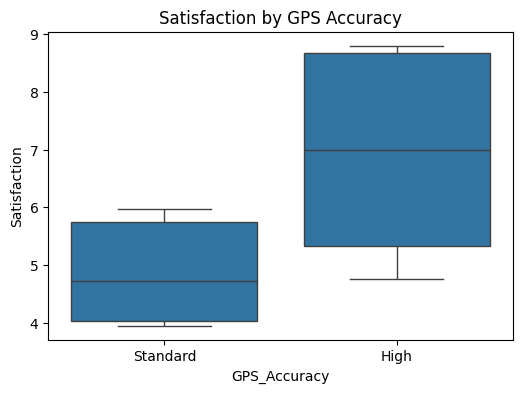

In [20]:
# Boxplots
plt.figure(figsize=(6,4))
sns.boxplot(x="GPS_Accuracy", y="Satisfaction", data=data)
plt.title("Satisfaction by GPS Accuracy")
plt.show()

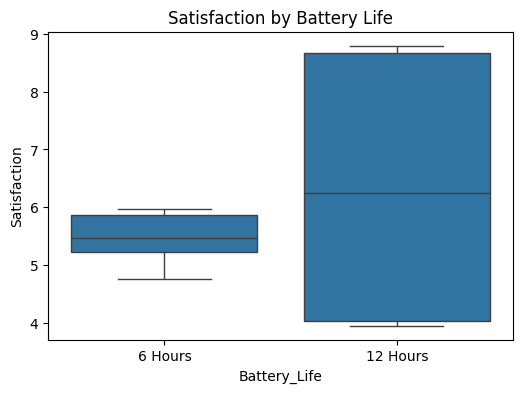

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Battery_Life", y="Satisfaction", data=data)
plt.title("Satisfaction by Battery Life")
plt.show()

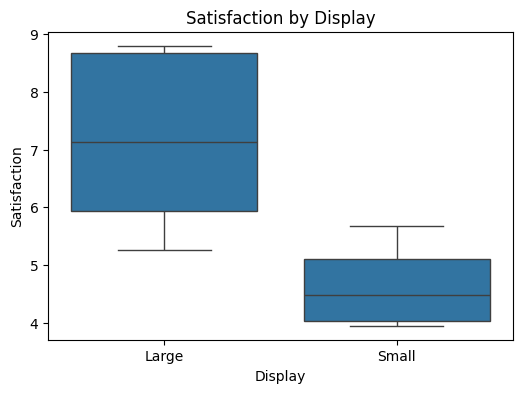

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Display", y="Satisfaction", data=data)
plt.title("Satisfaction by Display")
plt.show()

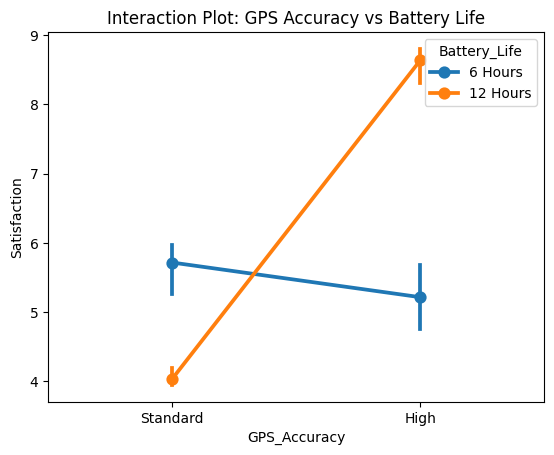

In [23]:
# Interaction-style plots
sns.pointplot(x="GPS_Accuracy", y="Satisfaction", hue="Battery_Life", data=data)
plt.title("Interaction Plot: GPS Accuracy vs Battery Life")
plt.show()

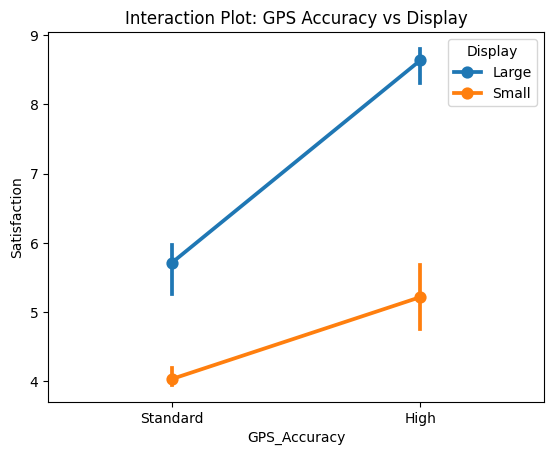

In [24]:
sns.pointplot(x="GPS_Accuracy", y="Satisfaction", hue="Display", data=data)
plt.title("Interaction Plot: GPS Accuracy vs Display")
plt.show()

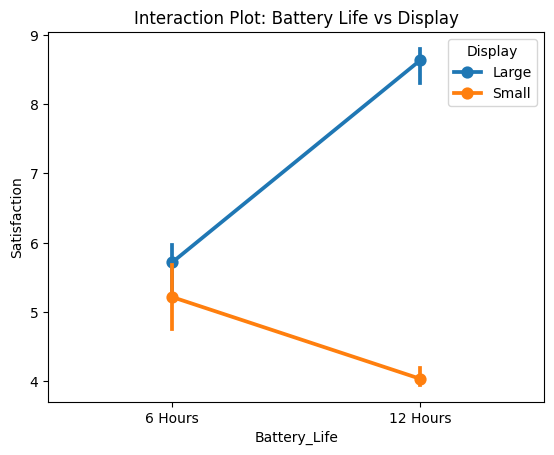

In [25]:
sns.pointplot(x="Battery_Life", y="Satisfaction", hue="Display", data=data)
plt.title("Interaction Plot: Battery Life vs Display")
plt.show()

Exploratory analysis was performed using summary statistics, boxplots, and interaction plots to examine how satisfaction ratings vary across the three factors.

The summary statistics and boxplots show clear differences across the factor levels. Bands with **High GPS accuracy** have higher satisfaction ratings than those with **Standard GPS accuracy**, and bands with a **Large display** have much higher satisfaction ratings than those with a **Small display**. The boxplot for Display shows almost no overlap between the two groups, indicating a very strong effect. Battery life shows a smaller and less consistent difference, with the 12-hour condition having higher variability.

The interaction plots provide additional insight. The plot for **GPS Accuracy and Battery Life** shows a strong non-parallel pattern, with the lines crossing, indicating a strong interaction. The effect of GPS accuracy depends heavily on battery life. The plot for **GPS Accuracy and Display** also shows non-parallel lines, suggesting a moderate to strong interaction, where the benefit of higher GPS accuracy is much larger when the display is Large. The plot for **Battery Life and Display** shows a very strong interaction, with one line increasing and the other decreasing, indicating that the effect of battery life depends strongly on display size.

Overall, these patterns suggest that the factor levels do not produce equal satisfaction ratings, and there is strong evidence of interaction effects. Therefore, the results support the **alternative hypotheses** more strongly than the null hypotheses.

However, because this is a fractional factorial design with defining relation \(I = ABC\), the main effects are aliased with two-way interactions. This means that the observed effects may be due to main effects, interactions, or a combination of both, and should be interpreted with caution.


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


In [26]:
## Question 8 Code ##
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Fit model with main effects only (since interactions are aliased)
model = smf.ols("Satisfaction ~ GPS_Accuracy + Battery_Life + Display", data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
GPS_Accuracy,12.587008,1.0,108.314163,0.000006
Battery_Life,2.262008,1.0,19.465113,0.002251
Display,19.482008,1.0,167.647257,0.000001
Residual,0.929667,8.0,NaN,NaN


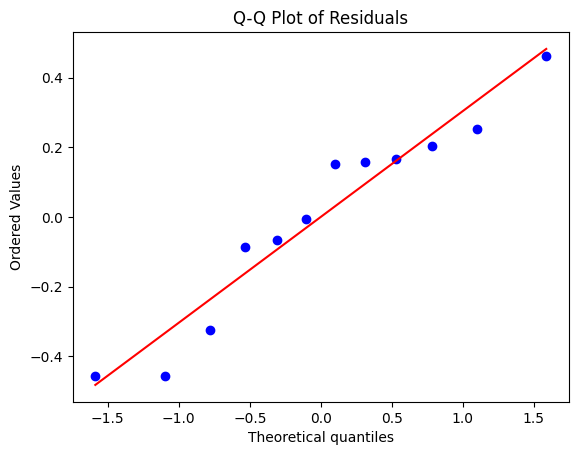

In [27]:
import scipy.stats as stats
import matplotlib.pyplot as plt

residuals = model.resid

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [28]:
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk Test Statistic: 0.9284071225902285
p-value: 0.36353430745848825


An ANOVA model was fit to the data including the main effects of GPS accuracy, battery life, and display size.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro-Wilk test.

From the Q-Q plot, the residuals do not fall perfectly on the reference line and show some deviations, with points appearing to move slightly above and below the line. However, there is no strong systematic pattern such as clear curvature or extreme departures in the tails. The deviations appear moderate rather than severe.

The Shapiro-Wilk test provides a formal assessment of normality. The p-value is 0.364, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality, indicating that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

It is also important to note that the sample size is small (n = 12), which can lead to greater variability in the Q-Q plot and make perfect alignment less likely.

Overall, although the Q-Q plot shows some deviation from the line, both the visual and formal methods suggest that the normality assumption is reasonably satisfied for this model.


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


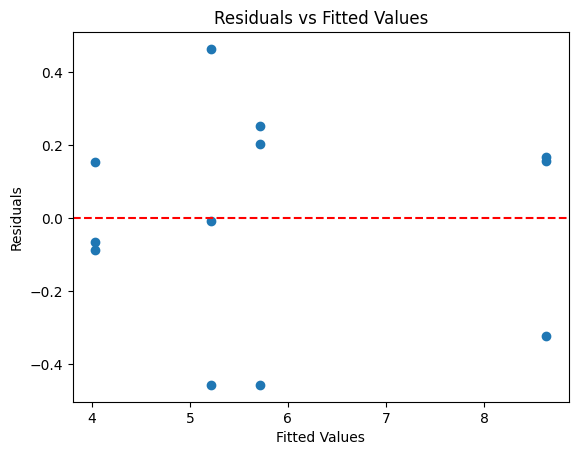

In [29]:
## Question 9 Code ##
import matplotlib.pyplot as plt

fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [30]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model.model.exog)

print("Breusch-Pagan Test Statistic:", bp_test[0])
print("p-value:", bp_test[1])

Breusch-Pagan Test Statistic: 4.390053765243515
p-value: 0.22230940809802568


The constant variance assumption was assessed using both a residuals versus fitted values plot and the Breusch-Pagan test.

From the residuals versus fitted values plot, the residuals appear to be randomly scattered around zero with no clear pattern or systematic structure. There is no evident funnel shape. While the spread of the residuals varies slightly across different fitted values, these variations are not consistent or systematic.

The Breusch-Pagan test provides a formal assessment of constant variance. The p-value is 0.222, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant variance, indicating that there is no strong statistical evidence of heteroscedasticity.

It is also important to note that the sample size is small (n = 12), which can lead to more variability in the residual plot and make the spread appear less uniform.

Overall, both the visual and formal methods suggest that the constant variance assumption is reasonably satisfied for this model.

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

The ANOVA model produced the following results for the main effects:

- **GPS Accuracy:** \(F = 108.314,\; p = 0.000006\)
- **Battery Life:** \(F = 19.465,\; p = 0.002251\)
- **Display:** \(F = 167.647,\; p = 0.000001\)

Based on these results, all three main effects are statistically significant at the 0.05 level. This suggests that GPS accuracy, battery life, and display size are each associated with differences in mean satisfaction ratings.

Among the three effects, **Display** appears to be the strongest, since it has the largest F-statistic and the smallest p-value. **GPS Accuracy** also appears to have a very strong effect, while **Battery Life** is statistically significant but weaker compared to the other two factors.

However, because this is a \(2^{3-1}\) fractional factorial design with defining relation \(I = ABC\), each main effect is aliased with a two-way interaction. Therefore, these results should be interpreted cautiously. For example, the observed effect of GPS Accuracy may also include the effect of the \(BC\) interaction, the effect of Battery Life may also include the \(AC\) interaction, and the effect of Display may also include the \(AB\) interaction.

Overall, the results provide strong evidence against the null hypotheses for all three main effects, but the estimated effects represent aliased effects rather than pure main effects alone.

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [31]:
## Question 11 Code ##
# Calculate main effects as difference in mean response at high level and low level

effect_A = data.groupby("GPS_Accuracy")["Satisfaction"].mean()["High"] - data.groupby("GPS_Accuracy")["Satisfaction"].mean()["Standard"]
effect_B = data.groupby("Battery_Life")["Satisfaction"].mean()["12 Hours"] - data.groupby("Battery_Life")["Satisfaction"].mean()["6 Hours"]
effect_C = data.groupby("Display")["Satisfaction"].mean()["Large"] - data.groupby("Display")["Satisfaction"].mean()["Small"]

print("Main effect of A (GPS Accuracy):", effect_A)
print("Main effect of B (Battery Life):", effect_B)
print("Main effect of C (Display):", effect_C)

Main effect of A (GPS Accuracy): 2.048333333333333
Main effect of B (Battery Life): 0.868333333333335
Main effect of C (Display): 2.548333333333333


The main effects were calculated as the difference between the mean satisfaction rating at the high level and the low level of each factor.

The estimated main effects are:

- **GPS Accuracy (A):** 2.048  
- **Battery Life (B):** 0.868  
- **Display (C):** 2.548  

These results indicate that increasing GPS accuracy from Standard to High increases mean satisfaction by about 2.05 points. Increasing battery life from 6 hours to 12 hours increases mean satisfaction by about 0.87 points. Increasing display size from Small to Large increases mean satisfaction by about 2.55 points.

Among the three factors, **Display** appears to be the most important because it has the largest main effect. **GPS Accuracy** is also important, with a similarly large effect. **Battery Life** appears to be less important, since its effect is much smaller in comparison.

However, because this is a \(2^{3-1}\) fractional factorial design with defining relation \(I = ABC\), these estimated main effects are aliased with two-way interactions. Therefore, the observed effects may be due to the main effects, the corresponding interactions, or a combination of both, and should be interpreted with caution.

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [32]:
## Question 12 Code ##
# Get sum of squares
ss_error = anova_table.loc["Residual", "sum_sq"]

# Calculate partial eta squared
eta_A = anova_table.loc["GPS_Accuracy", "sum_sq"] / (anova_table.loc["GPS_Accuracy", "sum_sq"] + ss_error)
eta_B = anova_table.loc["Battery_Life", "sum_sq"] / (anova_table.loc["Battery_Life", "sum_sq"] + ss_error)
eta_C = anova_table.loc["Display", "sum_sq"] / (anova_table.loc["Display", "sum_sq"] + ss_error)

print("Partial eta^2 (GPS Accuracy):", eta_A)
print("Partial eta^2 (Battery Life):", eta_B)
print("Partial eta^2 (Display):", eta_C)

Partial eta^2 (GPS Accuracy): 0.9312207575704331
Partial eta^2 (Battery Life): 0.7087213871504253
Partial eta^2 (Display): 0.954454170631922



The partial $\eta^2$ values were calculated using

$$
\eta_p^2 = \frac{SS_{\text{effect}}}{SS_{\text{effect}} + SS_{\text{error}}}
$$

The resulting values are:

- **GPS Accuracy (A):** $\eta_p^2 = 0.931$  
- **Battery Life (B):** $\eta_p^2 = 0.709$  
- **Display (C):** $\eta_p^2 = 0.954$  

These results indicate that all three factors explain a large proportion of the variability in satisfaction ratings. Among them, **Display** is the most important factor because it has the largest partial $\eta^2$ value, meaning it explains the greatest proportion of variation after accounting for the other factors.

**GPS Accuracy** is also very important, with a similarly large effect size. **Battery Life**, while still meaningful, has a smaller partial $\eta^2$ value compared to the other two factors, indicating that it explains less variation in satisfaction.

However, because this is a $2^{3-1}$ fractional factorial design with defining relation $I = ABC$, these effects are aliased with two-way interactions. Therefore, the estimated importance of each factor may also reflect the influence of corresponding interaction effects, and the results should be interpreted with caution.

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?

Based on the results of the exploratory analysis, ANOVA model, main effects, and partial $\eta^2$ values, all three factors — GPS accuracy, battery life, and display size — have meaningful effects on user satisfaction. Among these, **Display** appears to be the most important factor, followed closely by **GPS Accuracy**, while **Battery Life** has a smaller but still noticeable effect.

The exploratory analysis and treatment-combination means show that the highest average satisfaction rating was observed for the combination **High GPS Accuracy + 12 Hours Battery Life + Large Display**, with a mean of approximately **8.63**. In contrast, the lowest satisfaction was observed for **Standard GPS Accuracy + 12 Hours Battery Life + Small Display**, with a mean of about **4.04**.

The ANOVA results further support these findings, showing that all three factors are statistically significant, with Display having the strongest effect, followed by GPS Accuracy and then Battery Life. The partial $\eta^2$ values also confirm this ranking, indicating that Display explains the largest proportion of variation in satisfaction.

Based on these results, the recommended combination for the fitness band manufacturer is:

- **GPS Accuracy:** High  
- **Battery Life:** 12 Hours  
- **Display:** Large  

This combination is recommended because it produces the highest observed satisfaction and aligns with the strongest factor effects identified in the analysis.

However, because this is a $2^{3-1}$ fractional factorial design with defining relation $I = ABC$, the estimated main effects are aliased with two-way interactions. Therefore, this recommendation should be interpreted as the best-performing observed combination in this experiment, while recognizing that some of the observed effects may also reflect interaction effects.